In [3]:
import sys
from pathlib import Path


p = Path.cwd()
while p != p.parent and not (p / "kxor_code").exists():
    p = p.parent

sys.path.insert(0, str(p))
print("Added to sys.path:", p)


Added to sys.path: /Users/daphnejanissen/Documents/DSDM/Quantum Research Project/QuarticSpeedupK-XOR


In [ ]:
import os
import glob
import time
import numpy as np


# Load instance directly from .npz 
def load_kxor_npz(path: str):
    data = np.load(path, allow_pickle=False)
    n = int(data["n"])
    m = int(data["m"])
    scopes = data["scopes"]  
    b = data["b"]            
    return n, m, scopes, b

def b_to_rhs_bit(b):
    """
    Convert RHS b in {+1, -1} into parity bit in {0,1}:
      b = +1 -> rhs_bit = 0
      b = -1 -> rhs_bit = 1
    """
    b = int(b)
    if b == 1:
        return 0
    if b == -1:
        return 1
    raise ValueError(f"Unexpected RHS value b={b}; expected ±1.")

def guiding_state_counts_chunked(n, clauses, chunk_size=1<<20, dtype=np.uint16):
    """
    Computes s[x] = number of clauses satisfied by assignment x for all x in {0,1}^n,
    using chunking to control memory.

    Returns:
        s: np.ndarray of shape (2^n,) with integer counts in [0, m]
    """
    N = 1 << n
    s = np.zeros(N, dtype=dtype)

    # Precompute masks and rhs bits
    masks = []
    rhs_bits = []
    for indices, rhs_bit in clauses:
        mask = 0
        for i in indices:
            mask |= (1 << int(i))
        masks.append(np.uint32(mask))
        rhs_bits.append(np.uint32(int(rhs_bit)))

    # Process in blocks
    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)

        k = np.arange(start, end, dtype=np.uint32)  # indices of assignments in this block
        s_block = np.zeros(end - start, dtype=dtype)

        for mask, rhs_bit in zip(masks, rhs_bits):
            x = (k & mask).astype(np.uint32)

            # parity of x (bit parity)
            x ^= x >> 16
            x ^= x >> 8
            x ^= x >> 4
            x ^= x >> 2
            x ^= x >> 1
            parity = x & 1

            s_block += (parity == rhs_bit)

        s[start:end] = s_block

    return s

def prepare_guiding_state_for_npz(path, chunk_size=1<<20, dtype=np.uint16, max_n=24):
    """
    Loads one .npz k-XOR instance and times guiding-state computation.
    Skips if n > max_n (because 2^n is too large).
    """
    n, m, scopes, b = load_kxor_npz(path)

    if n > max_n:
        return {
            "path": path,
            "n": n,
            "m": m,
            "skipped": True,
            "reason": f"n={n} > max_n={max_n}; full 2^n guiding state too large.",
            "seconds": None,
        }

    clauses = [(row.tolist(), b_to_rhs_bit(bb)) for row, bb in zip(scopes, b)]

    t0 = time.perf_counter()
    s = guiding_state_counts_chunked(n=n, clauses=clauses, chunk_size=chunk_size, dtype=dtype)
    t1 = time.perf_counter()

    return {
        "path": path,
        "n": n,
        "m": m,
        "skipped": False,
        "seconds": t1 - t0,
        "s_dtype": str(s.dtype),
        "s_sum": int(s.sum()),
        "s_min": int(s.min()),
        "s_max": int(s.max()),
        # If you want to keep the full array (can be big), uncomment:
        # "s": s,
    }


# CONFIG: choose which instances to run
folder = "data/problem_instances"   

# Run ONLY instances with   
N_LOW_EXCLUSIVE = 11
N_HIGH_EXCLUSIVE = 31

# Guiding-state computation settings
chunk_size = 1 << 20   # 1,048,576 assignments per block
max_n = 30            # safety cutoff; n=25 will be skipped unless you raise this
dtype = np.uint16      # safe for m up to 65535

# Run timing over selected files
all_files = sorted(glob.glob(os.path.join(folder, "*.npz")))
print(f"Found {len(all_files)} .npz files in {folder}")

selected_files = []
for f in all_files:
    n, m, scopes, b = load_kxor_npz(f)
    if (n > N_LOW_EXCLUSIVE) and (n < N_HIGH_EXCLUSIVE):
        selected_files.append(f)

print(f"Selected {len(selected_files)} files with {N_LOW_EXCLUSIVE} < n < {N_HIGH_EXCLUSIVE}\n")

timings = []
for i, path in enumerate(selected_files, 1):
    info = prepare_guiding_state_for_npz(path, chunk_size=chunk_size, dtype=dtype, max_n=max_n)

    if info["skipped"]:
        print(f"[{i}/{len(selected_files)}] SKIP n={info['n']}, m={info['m']} -> {info['reason']}")
    else:
        print(f"[{i}/{len(selected_files)}] OK   n={info['n']}, m={info['m']} "
              f"time={info['seconds']:.3f}s  s_max={info['s_max']}")
        timings.append(info)

# Summary
if timings:
    secs = np.array([t["seconds"] for t in timings], dtype=float)
    print("\nTiming summary:")
    print(f"count  = {len(secs)}")
    print(f"min    = {secs.min():.3f}s")
    print(f"median = {np.median(secs):.3f}s")
    print(f"mean   = {secs.mean():.3f}s")
    print(f"max    = {secs.max():.3f}s")
else:
    print("\nNo instances were processed (all skipped or none selected).")



Found 846 .npz files in data/problem_instances
Selected 846 files with 11 < n < 31

[1/846] OK   n=12, m=116 time=0.001s  s_max=74
[2/846] OK   n=12, m=116 time=0.001s  s_max=78
[3/846] OK   n=12, m=116 time=0.001s  s_max=79
[4/846] OK   n=12, m=116 time=0.001s  s_max=97
[5/846] OK   n=12, m=116 time=0.001s  s_max=108
[6/846] OK   n=12, m=116 time=0.001s  s_max=116
[7/846] OK   n=12, m=75 time=0.001s  s_max=53
[8/846] OK   n=12, m=75 time=0.001s  s_max=52
[9/846] OK   n=12, m=75 time=0.001s  s_max=58
[10/846] OK   n=12, m=75 time=0.001s  s_max=60
[11/846] OK   n=12, m=75 time=0.001s  s_max=64
[12/846] OK   n=12, m=75 time=0.001s  s_max=75
[13/846] OK   n=12, m=78 time=0.001s  s_max=49
[14/846] OK   n=12, m=78 time=0.001s  s_max=51
[15/846] OK   n=12, m=78 time=0.001s  s_max=55
[16/846] OK   n=12, m=78 time=0.001s  s_max=62
[17/846] OK   n=12, m=78 time=0.001s  s_max=68
[18/846] OK   n=12, m=78 time=0.001s  s_max=78
[19/846] OK   n=12, m=92 time=0.001s  s_max=58
[20/846] OK   n=12, m=92

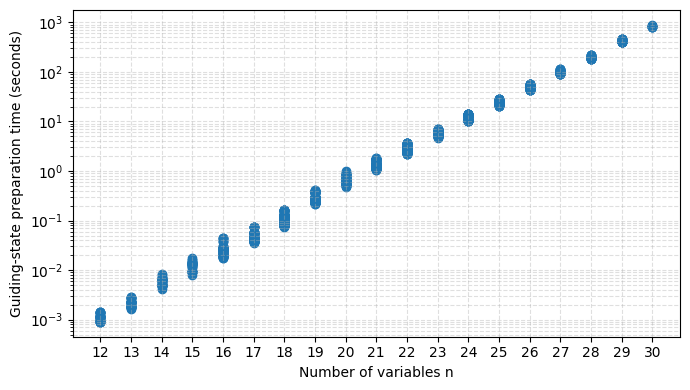

In [ ]:
import matplotlib.pyplot as plt

ns = [t["n"] for t in timings]
times = [t["seconds"] for t in timings]

plt.figure(figsize=(7, 4))
plt.scatter(ns, times)

plt.xlabel("Number of variables n")
plt.ylabel("Guiding-state preparation time (seconds)")
plt.yscale("log")

plt.xticks(sorted(set(ns)))   # ← integers only

plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



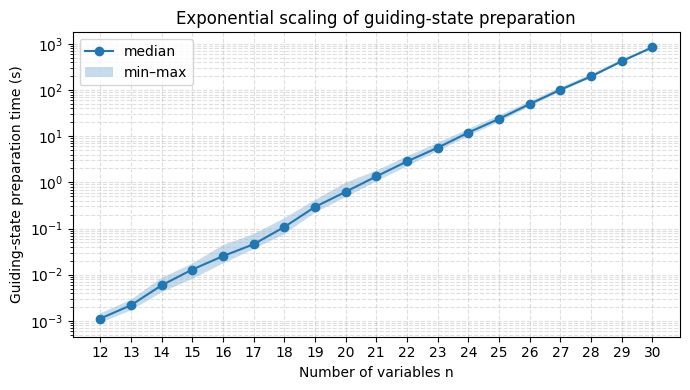

In [ ]:
from collections import defaultdict

grouped = defaultdict(list)
for t in timings:
    grouped[t["n"]].append(t["seconds"])

ns_sorted = sorted(grouped.keys())
medians = [np.median(grouped[n]) for n in ns_sorted]
mins = [np.min(grouped[n]) for n in ns_sorted]
maxs = [np.max(grouped[n]) for n in ns_sorted]

plt.figure(figsize=(7,4))
plt.plot(ns_sorted, medians, marker="o", label="median")
plt.fill_between(ns_sorted, mins, maxs, alpha=0.25, label="min–max")

plt.yscale("log")
plt.xticks(ns_sorted)
plt.xlabel("Number of variables n")
plt.ylabel("Guiding-state preparation time (s)")
plt.title("Exponential scaling of guiding-state preparation")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


/var/folders/l4/zc_99c5j7qx24lqr71p6zwjm0000gn/T/ipykernel_7611/4162799178.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ns_sorted, showfliers=False)


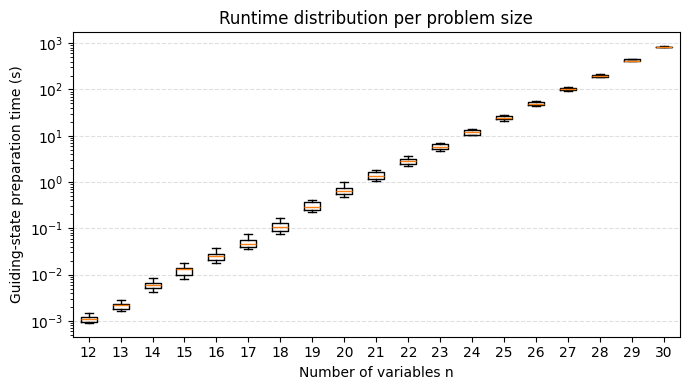

In [14]:
data = [grouped[n] for n in ns_sorted]

plt.figure(figsize=(7,4))
plt.boxplot(data, labels=ns_sorted, showfliers=False)

plt.yscale("log")
plt.xlabel("Number of variables n")
plt.ylabel("Guiding-state preparation time (s)")
plt.title("Runtime distribution per problem size")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


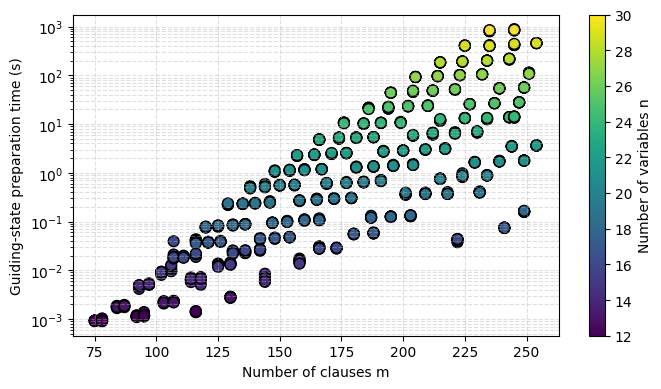

In [ ]:
ms = np.array([t["m"] for t in timings])
times = np.array([t["seconds"] for t in timings])
ns = np.array([t["n"] for t in timings])

plt.figure(figsize=(7, 4))

sc = plt.scatter(
    ms,
    times,
    c=ns,                # color by n
    cmap="viridis",
    s=60,
    edgecolors="black"
)

plt.xlabel("Number of clauses m")
plt.ylabel("Guiding-state preparation time (s)")
plt.yscale("log")

cbar = plt.colorbar(sc)
cbar.set_label("Number of variables n")

plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



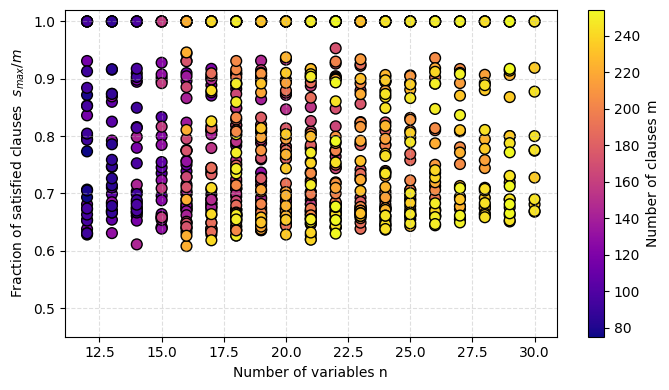

In [ ]:
ns = np.array([t["n"] for t in timings])
ms = np.array([t["m"] for t in timings])
smax = np.array([t["s_max"] for t in timings])

ratio = smax / ms

plt.figure(figsize=(7,4))
sc = plt.scatter(
    ns,
    ratio,
    c=ms,
    cmap="plasma",
    s=60,
    edgecolors="black"
)

plt.xlabel("Number of variables n")
plt.ylabel("Fraction of satisfied clauses  $s_{max}/m$")
plt.ylim(0.45, 1.02)

cbar = plt.colorbar(sc)
cbar.set_label("Number of clauses m")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


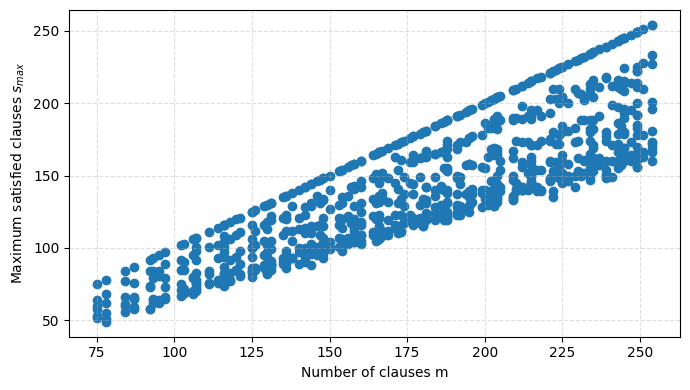

In [19]:
plt.figure(figsize=(7,4))
plt.scatter(ms, smax)

plt.xlabel("Number of clauses m")
plt.ylabel("Maximum satisfied clauses $s_{max}$")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


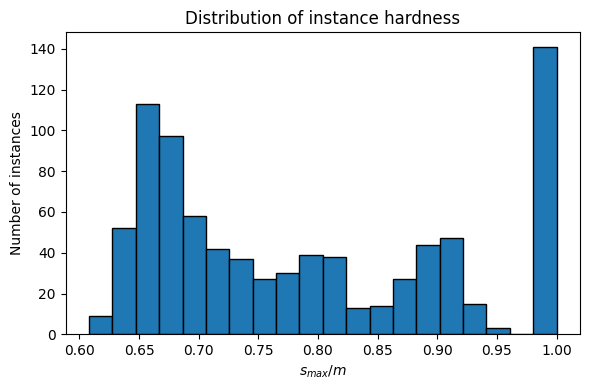

In [20]:
plt.figure(figsize=(6,4))
plt.hist(ratio, bins=20, edgecolor="black")

plt.xlabel("$s_{max}/m$")
plt.ylabel("Number of instances")
plt.title("Distribution of instance hardness")
plt.tight_layout()
plt.show()


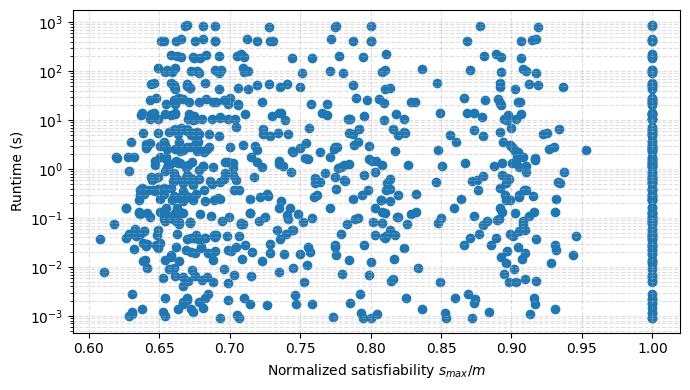

In [21]:
plt.figure(figsize=(7,4))
plt.scatter(ratio, times)

plt.xlabel("Normalized satisfiability $s_{max}/m$")
plt.ylabel("Runtime (s)")
plt.yscale("log")

plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
